In [3]:
!pip install pandas matplotlib seaborn -q

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# =====================
# LOAD BTC
# =====================
btc = pd.read_csv("btc_raw.csv")

# BTC has different column names — rename them
btc = btc.rename(columns={
    "Timestamp":           "timestamp",
    "Open":                "open",
    "High":                "high",
    "Low":                 "low",
    "Close":               "close",
    "Volume_(Currency)":   "volume"
})

# BTC timestamp is in Unix seconds — convert to readable date
btc["timestamp"] = pd.to_datetime(btc["timestamp"], unit="s")

# Remove rows where close price is 0 or missing
btc = btc[btc["close"] > 0].dropna(subset=["close"])
btc = btc.sort_values("timestamp").reset_index(drop=True)

print("=== BTC ===")
print(f"Total rows  : {len(btc):,}")
print(f"Date range  : {btc['timestamp'].min()} → {btc['timestamp'].max()}")
print(f"Columns     : {list(btc.columns)}")
print(f"Missing vals: {btc.isnull().sum().sum()}")
print(btc.head(3))

=== BTC ===
Total rows  : 1,259,924
Date range  : 2012-01-01 00:01:00 → 2014-05-24 22:44:00
Columns     : ['timestamp', 'open', 'high', 'low', 'close', 'Volume']
Missing vals: 0
            timestamp  open  high   low  close  Volume
0 2012-01-01 00:01:00  4.58  4.58  4.58   4.58     0.0
1 2012-01-01 00:02:00  4.58  4.58  4.58   4.58     0.0
2 2012-01-01 00:03:00  4.58  4.58  4.58   4.58     0.0


In [5]:
# =====================
# LOAD ETH, SOL, ADA
# =====================
eth = pd.read_csv("eth_raw.csv")
sol = pd.read_csv("sol_raw.csv")
ada = pd.read_csv("ada_raw.csv")

# These have standard column names — just lowercase them
for df in [eth, sol, ada]:
    df.columns = [c.lower() for c in df.columns]

# Convert date column
for df in [eth, sol, ada]:
    df["date"] = pd.to_datetime(df["date"])
    df.rename(columns={"date":"timestamp"}, inplace=True)
    df.sort_values("timestamp", inplace=True)
    df.reset_index(drop=True, inplace=True)

print("\n=== ETH ===")
print(f"Rows: {len(eth):,} | Range: {eth['timestamp'].min()} → {eth['timestamp'].max()}")
print(f"Columns: {list(eth.columns)}")

print("\n=== SOL ===")
print(f"Rows: {len(sol):,} | Range: {sol['timestamp'].min()} → {sol['timestamp'].max()}")

print("\n=== ADA ===")
print(f"Rows: {len(ada):,} | Range: {ada['timestamp'].min()} → {ada['timestamp'].max()}")


=== ETH ===
Rows: 2,160 | Range: 2015-08-08 23:59:59 → 2021-07-06 23:59:59
Columns: ['sno', 'name', 'symbol', 'timestamp', 'high', 'low', 'open', 'close', 'volume', 'marketcap']

=== SOL ===
Rows: 452 | Range: 2020-04-11 23:59:59 → 2021-07-06 23:59:59

=== ADA ===
Rows: 1,374 | Range: 2017-10-02 23:59:59 → 2021-07-06 23:59:59


In [7]:
print("=== MISSING VALUES ===\n")

for name, df in [("BTC", btc), ("ETH", eth), ("SOL", sol), ("ADA", ada)]:
    print(f"{name}:")

    # Check only columns that actually exist
    cols = ["open", "high", "low", "close", "volume"]
    existing_cols = [c for c in cols if c in df.columns]

    print(df[existing_cols].isnull().sum())
    print()

=== MISSING VALUES ===

BTC:
open     0
high     0
low      0
close    0
dtype: int64

ETH:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

SOL:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

ADA:
open      0
high      0
low       0
close     0
volume    0
dtype: int64



In [11]:
# STEP 6 — BASIC STATISTICS

# Rename BTC Volume column
btc.rename(columns={"Volume": "volume"}, inplace=True)

# BTC Statistics
print("=== BTC STATISTICS ===")
print(btc[["open", "high", "low", "close", "volume"]].describe())

# ETH Statistics
print("\n=== ETH STATISTICS ===")
print(eth[["open", "high", "low", "close", "volume"]].describe())

=== BTC STATISTICS ===
               open          high           low         close        volume
count  1.259924e+06  1.259924e+06  1.259924e+06  1.259924e+06  1.259924e+06
mean   1.813509e+02  1.815300e+02  1.811588e+02  1.813490e+02  6.412518e+00
std    2.649570e+02  2.652648e+02  2.646301e+02  2.649586e+02  3.275319e+01
min    3.800000e+00  3.800000e+00  3.800000e+00  3.800000e+00  0.000000e+00
25%    9.960000e+00  9.960000e+00  9.950000e+00  9.960000e+00  0.000000e+00
50%    4.685000e+01  4.685000e+01  4.684000e+01  4.685000e+01  0.000000e+00
75%    1.679900e+02  1.680700e+02  1.678025e+02  1.679800e+02  1.427786e+00
max    1.163000e+03  1.163000e+03  1.162990e+03  1.163000e+03  4.111876e+03

=== ETH STATISTICS ===
              open         high          low        close        volume
count  2160.000000  2160.000000  2160.000000  2160.000000  2.160000e+03
mean    382.879899   398.258568   365.592589   383.910691  7.057058e+09
std     599.719862   628.082281   566.611523   601.07

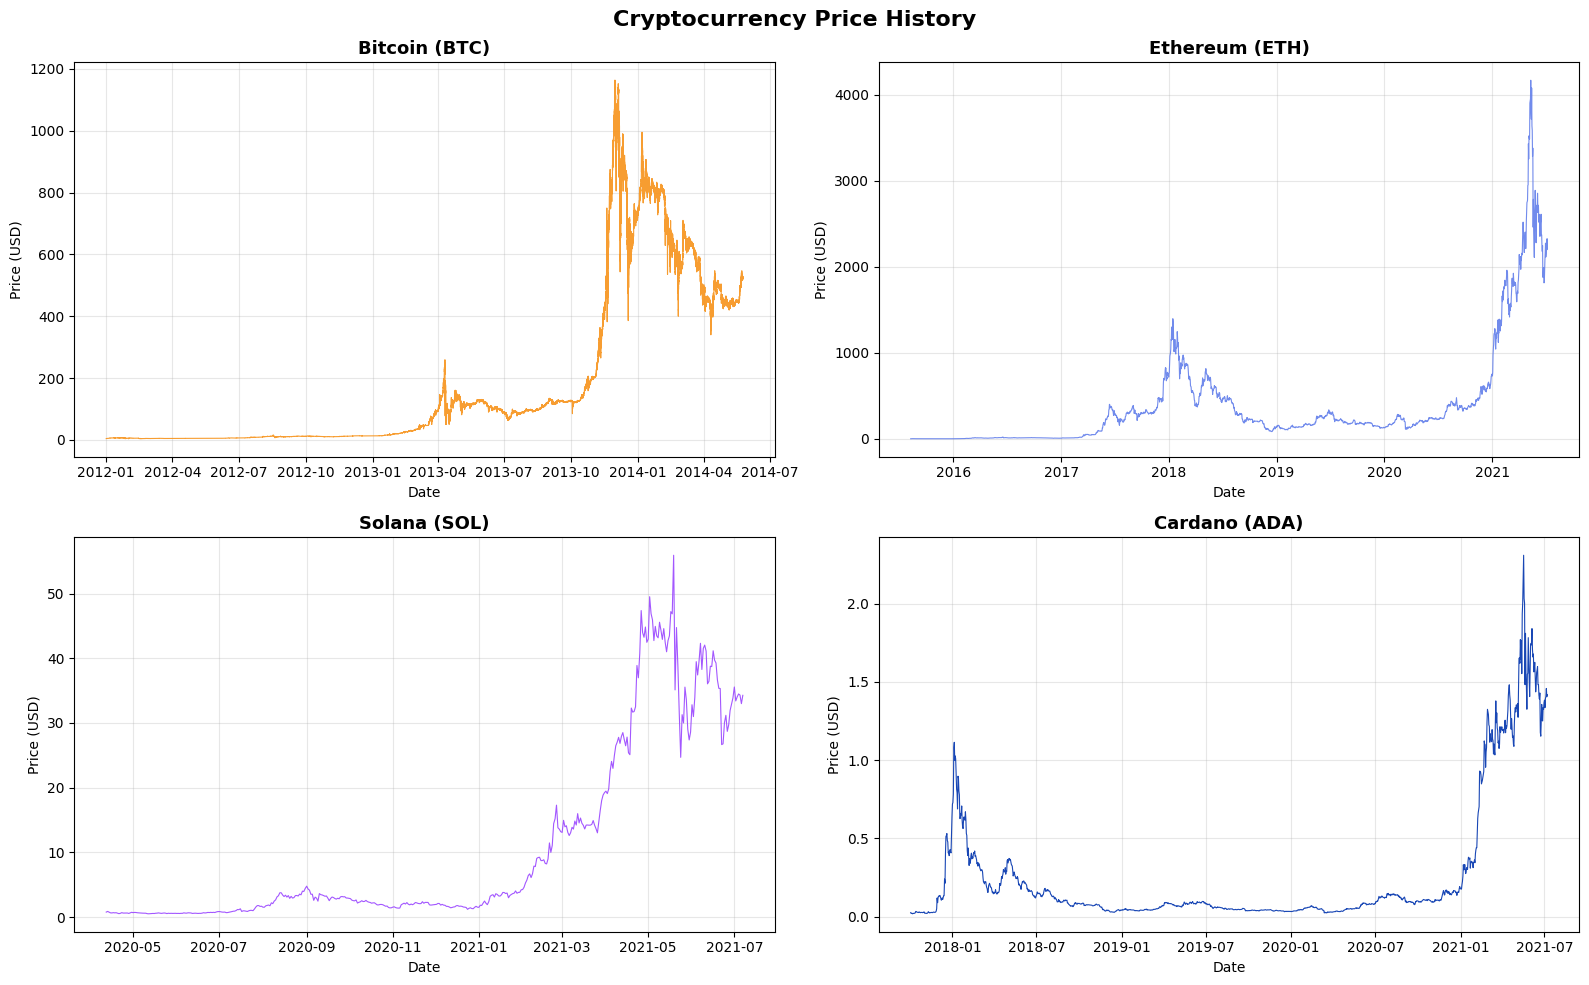

Saved: price_history_all_coins.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Cryptocurrency Price History",
             fontsize=16, fontweight="bold")

coins_data = [
    ("Bitcoin (BTC)",  btc,  "#f7931a"),
    ("Ethereum (ETH)", eth,  "#627eea"),
    ("Solana (SOL)",   sol,  "#9945ff"),
    ("Cardano (ADA)",  ada,  "#0033ad")
]

for i, (name, df, color) in enumerate(coins_data):
    ax = axes[i//2][i%2]
    ax.plot(df["timestamp"], df["close"],
            color=color, linewidth=0.8, alpha=0.9)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("price_history_all_coins.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: price_history_all_coins.png")

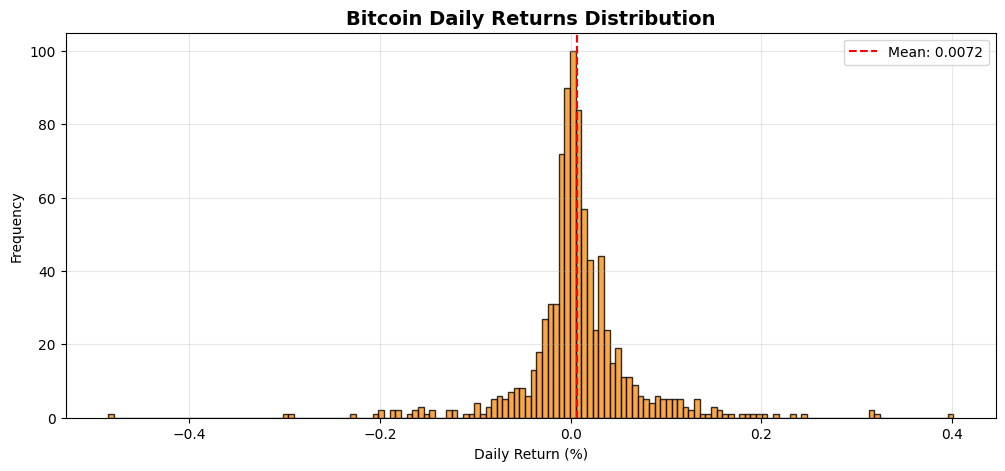

BTC Mean Daily Return : 0.0072
BTC Return Std Dev    : 0.0604
BTC Max Daily Gain    : 0.4014
BTC Max Daily Loss    : -0.4852


In [13]:
# Resample BTC to daily first (it is currently minute-level)
btc_daily = btc.set_index("timestamp")["close"] \
               .resample("D").last().dropna()

# Calculate daily returns
btc_returns = btc_daily.pct_change().dropna()

plt.figure(figsize=(12, 5))
plt.hist(btc_returns, bins=150,
         color="#f7931a", edgecolor="black",
         alpha=0.8)
plt.title("Bitcoin Daily Returns Distribution",
          fontsize=14, fontweight="bold")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(btc_returns.mean(), color="red",
            linestyle="--", label=f"Mean: {btc_returns.mean():.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("btc_returns_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"BTC Mean Daily Return : {btc_returns.mean():.4f}")
print(f"BTC Return Std Dev    : {btc_returns.std():.4f}")
print(f"BTC Max Daily Gain    : {btc_returns.max():.4f}")
print(f"BTC Max Daily Loss    : {btc_returns.min():.4f}")

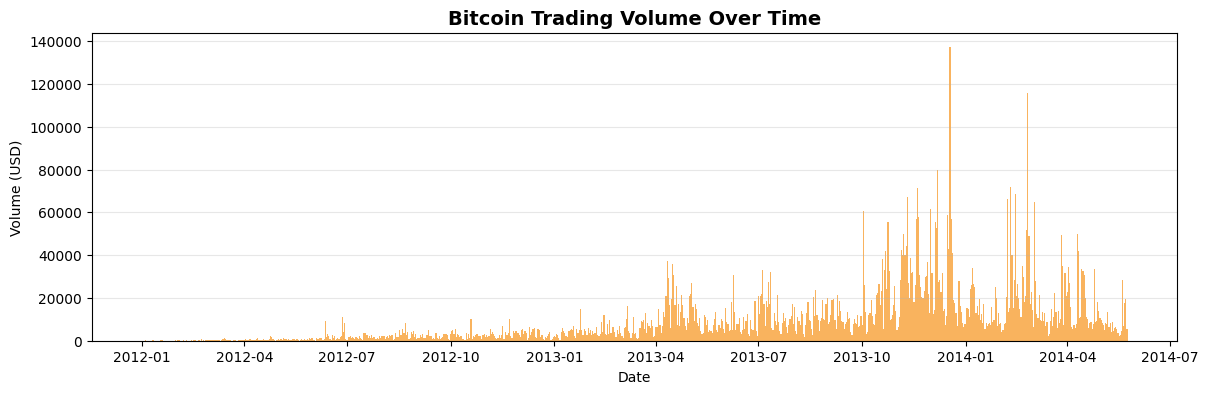

In [14]:
# Resample volume to daily
btc_vol = btc.set_index("timestamp")["volume"] \
             .resample("D").sum().dropna()

plt.figure(figsize=(14, 4))
plt.bar(btc_vol.index, btc_vol.values,
        color="#f7931a", alpha=0.7, width=1.0)
plt.title("Bitcoin Trading Volume Over Time",
          fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Volume (USD)")
plt.grid(True, alpha=0.3, axis="y")
plt.savefig("btc_volume.png",
            dpi=150, bbox_inches="tight")
plt.show()

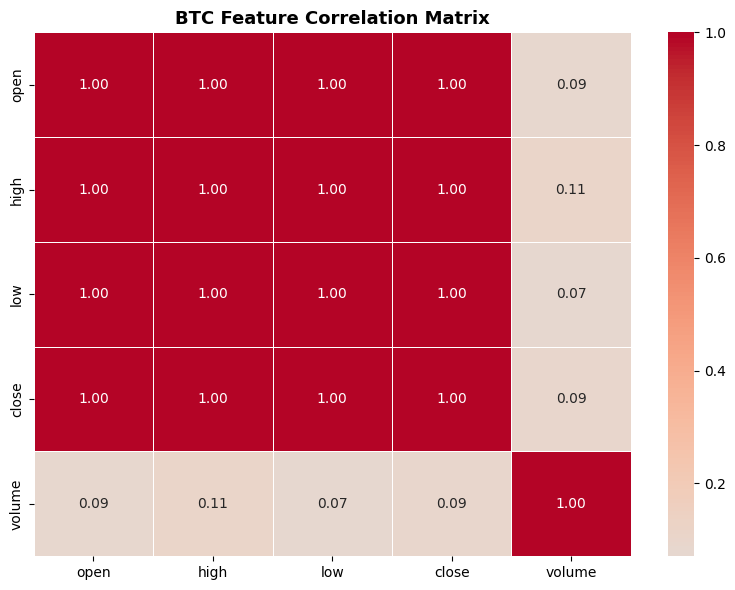

High correlation between open/high/low/close is expected.
Volume has lower correlation — it adds independent information.


In [15]:
# Use last 5000 BTC rows for correlation
btc_sample = btc[["open","high","low","close","volume"]] \
               .tail(5000).dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(
    btc_sample.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("BTC Feature Correlation Matrix",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("btc_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("High correlation between open/high/low/close is expected.")
print("Volume has lower correlation — it adds independent information.")

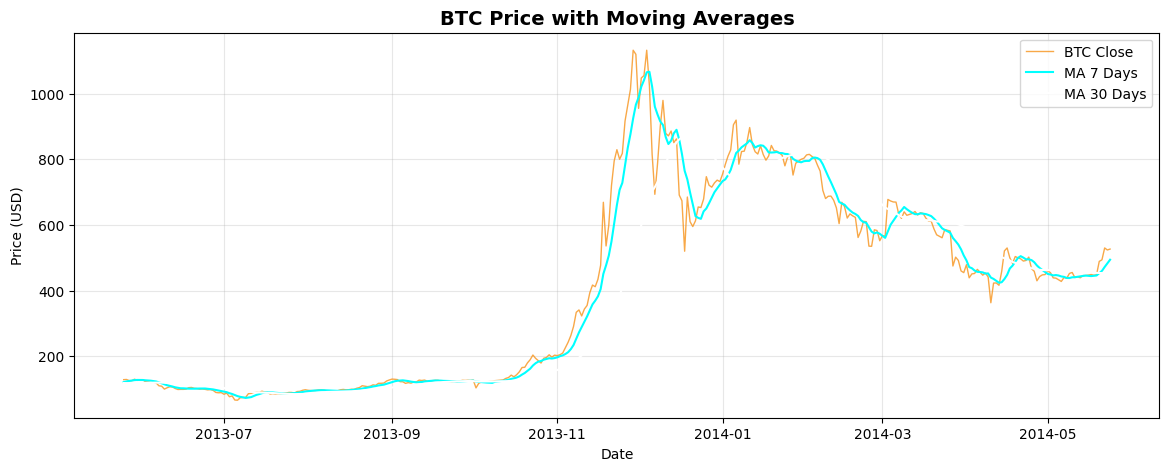

This chart explains why MA7 and MA30 are useful features.
MA smooths out noise and captures trend direction.


In [16]:
# Show what MA7 and MA30 look like on BTC
btc_daily_df = btc_daily.reset_index()
btc_daily_df.columns = ["timestamp","close"]
btc_daily_df["MA7"]  = btc_daily_df["close"].rolling(7).mean()
btc_daily_df["MA30"] = btc_daily_df["close"].rolling(30).mean()

# Show last 365 days only for clarity
last_year = btc_daily_df.tail(365)

plt.figure(figsize=(14, 5))
plt.plot(last_year["timestamp"], last_year["close"],
         label="BTC Close", color="#f7931a",
         linewidth=1.0, alpha=0.8)
plt.plot(last_year["timestamp"], last_year["MA7"],
         label="MA 7 Days", color="cyan",
         linewidth=1.5)
plt.plot(last_year["timestamp"], last_year["MA30"],
         label="MA 30 Days", color="white",
         linewidth=1.5)
plt.title("BTC Price with Moving Averages",
          fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("btc_moving_averages.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("This chart explains why MA7 and MA30 are useful features.")
print("MA smooths out noise and captures trend direction.")

## EDA OBSERVATIONS

### Dataset Summary
- **BTC:** 1,259,924 rows, 2012-01-01 to 2014-05-24, minute-level data
- **ETH:** 2,160 rows, 2015-08-08 to 2021-07-06, daily data
- **SOL:** 452 rows, 2020-04-11 to 2021-07-06, daily data
- **ADA:** 1,374 rows, 2017-10-02 to 2021-07-06, daily data

### Key Findings
1. BTC has the largest dataset with **1,259,924 minute-level records**.
2. ETH, SOL, and ADA contain smaller datasets with daily-level records.
3. BTC prices in this dataset range from approximately **$3.80 to $1,163**.
4. The average BTC closing price is approximately **$181.35**.
5. ETH prices show a much wider range, with the closing price reaching approximately **$4,168.70**.
6. Open, High, Low, and Close prices are highly related because they represent different price points within the same trading period.
7. Volume provides additional information about trading activity and can be useful alongside price features.
8. Moving averages such as MA7 and MA30 help smooth short-term price fluctuations and identify the overall price trend.
9. Daily-return analysis can be used to understand cryptocurrency price volatility and extreme price movements.

### Missing Values
- **BTC:** 0 missing values after cleaning
- **ETH:** 0 missing values
- **SOL:** 0 missing values
- **ADA:** 0 missing values

### Feature Engineering Justification
These EDA findings support the following feature engineering choices:

- **MA7:** captures short-term price trends
- **MA30:** captures longer-term price trends
- **volatility_7:** measures recent price variability/risk
- **prev_close:** captures information from the previous closing price
- **pct_change:** measures percentage price movement
